In [2]:
import pandas as pd
import numpy as np
import re
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display
import plotly.graph_objects as go
import warnings

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [3]:
## Loading Hotline Data
HL_base = pd.read_csv("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/trafficking_states_master.csv")
HL_base = HL_base.drop(columns=["% of total signals", "% of total cases"])

In [4]:
##Loading ICE Removal Data
ICE_base = pd.read_csv("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/ICERemovalsdata.csv",
                      encoding='latin-1')
##Selecting Most Important Columns
ICE_base = ICE_base.drop(columns=["Criminality", "Arresting Agency", "Criminality", "Country of Citizenship", "Fiscal Quarter", "Fiscal Month", "Month-Year"])

##Grouping by Area of Responsibility and Year to Find Removals
ICE_byyear = ICE_base.groupby(["Area of Responsibility (AOR)", "Fiscal Year"])["Removals"].sum().reset_index()

In [5]:
##Reading the AOR location data
AOR_merge = pd.read_csv("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/ICEEROmanualdatacleancompleted.csv")

##Making sure office names are only the areas they represent for merging
AOR_merge["office_name"] = AOR_merge["office_name"].str.replace(" Field Office", "", regex=False).str.strip()

##Exploding the AOR merged data such that each AOR state/area has it's own row
AOR_merge["area"] = AOR_merge["area"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
areas_exploded = AOR_merge.explode("area").reset_index(drop=True)

In [6]:
#Merging the state-level hotline data to convert it to AOR
HL_merged = pd.merge(HL_base, areas_exploded, left_on="State", right_on="area", how="left")

HL_byAOR = HL_merged.groupby(["office_name", "Year"])[["Signals received", "Cases identified"]].sum().reset_index()

In [65]:
##Merging Hotline and ICE Data
HL_ICE_merged = pd.merge(HL_byAOR, ICE_byyear, left_on=["office_name", "Year"], right_on=["Area of Responsibility (AOR)", "Fiscal Year"], how="right")

##Removing incomplete 2025 years
HL_ICE_merged = HL_ICE_merged[~HL_ICE_merged["Fiscal Year"].isin([2025])]

##Dropping NA Values and Renaming Columns
HL_ICE_merged = HL_ICE_merged.dropna()
HL_ICE_merged = HL_ICE_merged.rename(columns={
    "Signals received": "Signals_received",
    "Fiscal Year": "Fiscal_Year",
    "Cases identified": "Cases_identified",
    "Area of Responsibility (AOR)": "AOR"
})

HL_ICE_merged.head(n=10)

,office_name,Year,Signals_received,Cases_identified,AOR,Fiscal_Year,Removals
0,Atlanta,2021.0,2447.0,629.0,Atlanta,2021,2780
1,Atlanta,2022.0,1946.0,573.0,Atlanta,2022,2598
2,Atlanta,2023.0,1467.0,567.0,Atlanta,2023,5002
3,Atlanta,2024.0,1781.0,779.0,Atlanta,2024,6277
5,Baltimore,2024.0,358.0,179.0,Baltimore,2024,65
7,Boston,2021.0,822.0,232.0,Boston,2021,92
8,Boston,2022.0,566.0,185.0,Boston,2022,38
9,Boston,2023.0,580.0,210.0,Boston,2023,436
10,Boston,2024.0,644.0,308.0,Boston,2024,1017
12,Buffalo,2021.0,1668.0,404.0,Buffalo,2021,134


In [20]:
##Simple OLS with Robust SE
HL__Signal__on_year_rem_ = smf.ols("np.log(Q('Signals_received')) ~ np.log(Q('Removals'))", data=HL_ICE_merged).fit(cov_type='cluster', cov_kwds={'groups': HL_ICE_merged['AOR']})
print(HL__Signal__on_year_rem_.summary())

                                  OLS Regression Results                                 
Dep. Variable:     np.log(Q('Signals_received'))   R-squared:                       0.158
Model:                                       OLS   Adj. R-squared:                  0.148
Method:                            Least Squares   F-statistic:                     6.126
Date:                           Tue, 17 Mar 2026   Prob (F-statistic):             0.0211
Time:                                   16:31:05   Log-Likelihood:                -87.450
No. Observations:                             91   AIC:                             178.9
Df Residuals:                                 89   BIC:                             183.9
Df Model:                                      1                                         
Covariance Type:                         cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------

In [21]:
##OLS with TWFE and Robust SE
HL__Signal__on_year_rem_TWFE = smf.ols("np.log(Q('Signals_received')) ~ np.log(Q('Removals')) + C(Fiscal_Year) + C(AOR)", data=HL_ICE_merged).fit(cov_type='cluster', cov_kwds={'groups': HL_ICE_merged['AOR']})
print(HL__Signal__on_year_rem_TWFE.summary())

                                  OLS Regression Results                                 
Dep. Variable:     np.log(Q('Signals_received'))   R-squared:                       0.985
Model:                                       OLS   Adj. R-squared:                  0.979
Method:                            Least Squares   F-statistic:                     240.5
Date:                           Tue, 17 Mar 2026   Prob (F-statistic):           2.10e-18
Time:                                   16:31:06   Log-Likelihood:                 97.261
No. Observations:                             91   AIC:                            -138.5
Df Residuals:                                 63   BIC:                            -68.22
Df Model:                                     27                                         
Covariance Type:                         cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-------

C:\Users\Jesse\miniforge3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [32]:
##Bringing regression together with p-value stars, and exporting to LaTeX
table = Stargazer([HL__Signal__on_year_rem_, HL__Signal__on_year_rem_TWFE])

table.covariate_order(["np.log(Q('Removals'))", "Intercept"])

table.add_line("AOR and Fiscal Year FE", ["No", "Yes"])
table.rename_covariates({"np.log(Q('Removals'))": "Log(Removals)"})
table.title("Human Trafficking Hotline Signals on ICE Removals")

display(HTML(table.render_html()))

latex_table = table.render_latex()
with open("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/Images/hotlinesignalsonICEremovals", "w") as f:
    f.write(table.render_latex())

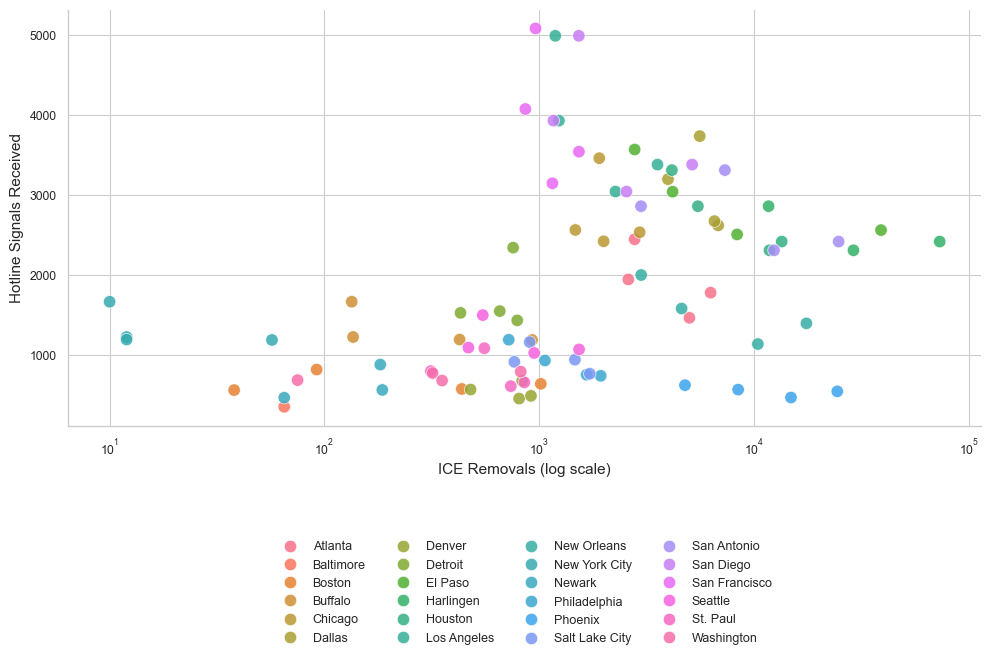

In [63]:
sns.set_theme(style='whitegrid', context='paper', font='Arial')

# Palette with enough colors
sns.set_palette('tab20')

# Figure size so nothing gets smushed
plt.figure(figsize=(10, 7))

ax = sns.scatterplot(data=HL_ICE_merged,
                     x='Removals', y='Signals_received',
                     hue='AOR',
                     s=80, alpha=0.85, edgecolor='white', linewidth=0.5)
#Scaling X by log because there is so much clustering on the lower end
plt.xscale('log')

# Titles and labels
plt.xlabel('ICE Removals (log scale)', fontsize=11)
plt.ylabel('Hotline Signals Received', fontsize=11)

#Looks gross without
sns.despine()

# Legend below
plt.legend(bbox_to_anchor=(0.5, -0.25),
           loc='upper center',
           ncols=4,
           frameon=False,  
           fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/Images/AORremscatter.pdf', bbox_inches='tight', dpi=300)

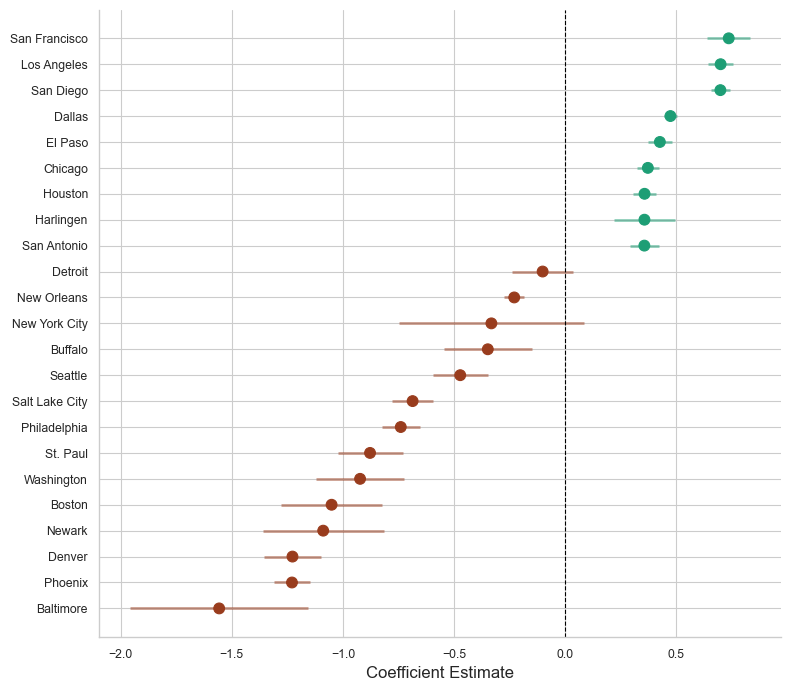

In [64]:
# Pull coefficients and CIs from your fitted model
TWFE = HL__Signal__on_year_rem_TWFE

coefs = TWFE.params.filter(like='C(AOR)')
ci_low = TWFE.conf_int()[0].filter(like='C(AOR)')
ci_high = TWFE.conf_int()[1].filter(like='C(AOR)')

#Cleaning label names
labels = [c.replace('C(AOR)[T.', '').replace(']', '') for c in coefs.index]

#Confidence intervals
df_plot = pd.DataFrame({'AOR': labels, 'coef': coefs.values,
                        'ci_low': ci_low.values, 'ci_high': ci_high.values})

# Sorting to make it sequential
df_plot = df_plot.sort_values('coef')

# Aesthetics
sns.set_theme(style='whitegrid', context='paper', font='Arial')
fig, ax = plt.subplots(figsize=(8, 7))

# Making a nice contrast
df_plot['color'] = df_plot['coef'].apply(lambda x: '#993C1D' if x < 0 else '#1D9E75')

# Plotting
ax.scatter(df_plot['coef'], df_plot['AOR'],
           color=df_plot['color'], zorder=3, s=60)
ax.hlines(df_plot['AOR'], df_plot['ci_low'], df_plot['ci_high'],
          color=df_plot['color'], alpha=0.5, linewidth=2)

# 0 Line
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')  # zero reference line

# Labels
ax.set_xlabel('Coefficient Estimate', fontsize=12)

# Looked gross without
sns.despine()

plt.tight_layout()

# Saving
plt.savefig('C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/Images/AORcoef.pdf', bbox_inches='tight', dpi=300)